In [ ]:
weights_path = os.path.join("..", "..", "..", "weights", "seed_count", "yolov8_seed_count_best.pt")
data_path = os.path.join("..", "..", "..", "sample_data", "raw_spread_seeds_lab")
manual_path = os.path.join('..', '..', '4_seed_area', '1_seed_area_sam2', 'manual_pixel_spread_seed.csv')
# weights_path = r"C:\Users\choto\OneDrive - Kansas State University\Agronomy_Research\NMSU_AI_workshop_2026\DL_for_Sorghum_Yield_Prediction\weights\seed_count\yolov8_seed_count_best.pt"
# data_path = r"C:\Users\choto\OneDrive - Kansas State University\Agronomy_Research\NMSU_AI_workshop_2026\DL_for_Sorghum_Yield_Prediction\sample_data\raw_spread_seeds_lab"
# manual_path = r"C:\Users\choto\OneDrive - Kansas State University\Agronomy_Research\NMSU_AI_workshop_2026\DL_for_Sorghum_Yield_Prediction\codes\4_seed_area\1_seed_area_sam2\manual_pixel_spread_seed.csv"

Import library

In [2]:
import os
import numpy as np
import cv2
import torch
import pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Check CUDA
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.cuda.empty_cache()
device

'cpu'

In [4]:
weights_path, data_path

('C:\\Users\\choto\\OneDrive - Kansas State University\\Agronomy_Research\\NMSU_AI_workshop_2026\\DL_for_Sorghum_Yield_Prediction\\weights\\seed_count\\yolov8_seed_count_best.pt',
 'C:\\Users\\choto\\OneDrive - Kansas State University\\Agronomy_Research\\NMSU_AI_workshop_2026\\DL_for_Sorghum_Yield_Prediction\\sample_data\\raw_spread_seeds_lab')

Total seeds: 2449


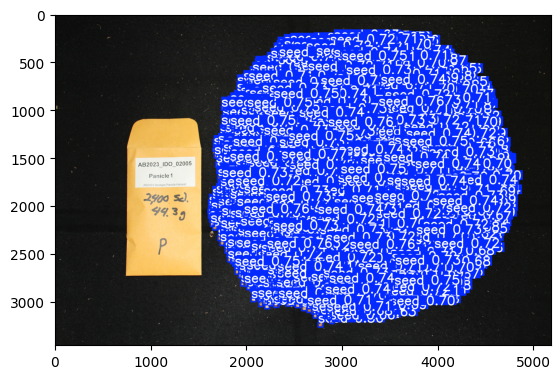

In [5]:
sample_image = os.path.join(data_path, '2005', '2005_1.jpg')
model = YOLO(weights_path)  # load a custom model
results = model(sample_image, max_det = 3000, conf = 0.1, verbose=False)
fig = plt.figure()
detect_img = results[0].plot()
detect_img = cv2.cvtColor(detect_img, cv2.COLOR_BGR2RGB)
boxes_fr = results[0].boxes.xywh.cpu().numpy()
print("Total seeds:", len(boxes_fr))
plt.imshow(detect_img)
plt.show()

## Dataframe created read the folders and images and put in the dataframe

In [7]:
# Load pixels-per-mm reference
df_ppi = pd.read_csv(manual_path)
df_ppi['Image_id'] = df_ppi['Image_id'].astype(str).str.strip().str.split('.').str[0]  # clean Image_id

# Build dataframe
df = pd.DataFrame(columns=[
    'id', 'image_name', 'rep', 'seed_counts',
    'avg_bbox_width_px', 'avg_bbox_height_px',
    'avg_bbox_width_mm', 'avg_bbox_height_mm',
    'avg_bbox_area_rect_mm2', 'avg_bbox_area_ellipse_mm2'
])

data = []
for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    r = 1
    images = [f for f in files if f.lower().endswith('jpg')]
    if not images:
        continue
    for file in files:
        if file.lower().endswith('jpg'):
            if '_1' in file:
                r = 1
            elif '_2' in file:
                r = 2
            elif '_3' in file:
                r = 3
            elif '_4' in file:
                r = 4
            data.append([folder_name, file, r])

df[['id', 'image_name', 'rep']] = data

# Initialize output directory and confidence value
output_dir = r'predicted_outputs'
conf_val = 0.1

for root, dirs, files in os.walk(data_path):
    folder_name = os.path.basename(root)
    if folder_name == os.path.basename(data_path):
        continue

    folder_output_dir = os.path.join(output_dir, folder_name)
    os.makedirs(folder_output_dir, exist_ok=True)
    image_folder_path = os.path.join(data_path, folder_name)
    images = [f for f in files if f.lower().endswith('jpg')]
    if not images:
        continue
    images.sort()

    for idx, img in enumerate(images):
        img_path = os.path.join(image_folder_path, img)

        # Perform inference
        result = model(img_path, max_det=3000, conf=conf_val, show_labels=False, show_conf=False)

        # Extract the bounding boxes
        boxes = result[0].boxes.xywh.cpu().numpy()
        num_boxes = len(boxes)

        mask = (df['id'] == folder_name) & (df['image_name'] == img)
        df.loc[mask, 'seed_counts'] = num_boxes

        # Prepend folder_name to match clipped image naming: e.g. '2005_2005_1'
        img_id  = folder_name + '_' + img.split('.')[0].strip()
        ppm_row = df_ppi.loc[df_ppi['Image_id'] == img_id, 'pixels_per_mm']

        if len(boxes) > 0 and not ppm_row.empty:
            ppm        = ppm_row.values[0]
            widths_px  = boxes[:, 2]
            heights_px = boxes[:, 3]

            avg_w_px = widths_px.mean()
            avg_h_px = heights_px.mean()
            avg_w_mm = avg_w_px / ppm
            avg_h_mm = avg_h_px / ppm

            # Rectangular area (secondary metric)
            avg_area_rect_mm2 = (widths_px * heights_px).mean() / (ppm ** 2)

            # Elliptical area (consistent with SAM2's π × r²)
            avg_area_ellipse_mm2 = (np.pi * (widths_px / 2) * (heights_px / 2)).mean() / (ppm ** 2)

            df.loc[mask, 'avg_bbox_width_px']         = avg_w_px
            df.loc[mask, 'avg_bbox_height_px']        = avg_h_px
            df.loc[mask, 'avg_bbox_width_mm']         = avg_w_mm
            df.loc[mask, 'avg_bbox_height_mm']        = avg_h_mm
            df.loc[mask, 'avg_bbox_area_rect_mm2']    = avg_area_rect_mm2
            df.loc[mask, 'avg_bbox_area_ellipse_mm2'] = avg_area_ellipse_mm2
        else:
            # Drop the row if no ppm found
            print(f"Dropping row: no ppm found for '{img_id}'")
            df.drop(df[mask].index, inplace=True)

        # Draw and save the bounding boxes on the image
        detect_img = result[0].plot()
        output_image_path = os.path.join(folder_output_dir, img)
        cv2.imwrite(output_image_path, detect_img)

# df.to_csv('predicted_panicle_seed_counts_spread_yolov8.csv', index=False)
df

Dropping row: no ppm found for '2005_2005_4'
Dropping row: no ppm found for '2009_2009_3'
Dropping row: no ppm found for '2009_2009_4'
Dropping row: no ppm found for '2013_2013_4'


,id,image_name,rep,seed_counts,avg_bbox_width_px,avg_bbox_height_px,avg_bbox_width_mm,avg_bbox_height_mm,avg_bbox_area_rect_mm2,avg_bbox_area_ellipse_mm2
0,2005,2005_1.JPG,1,2449,42.476326,41.077957,3.414496,3.302087,11.344155,8.909678
1,2005,2005_2.JPG,2,1611,50.133022,48.692513,3.137235,3.047091,9.626817,7.560884
2,2005,2005_3.JPG,3,1917,47.181606,44.776073,3.091848,2.934212,9.111473,7.156135
4,2009,2009_1.JPG,1,676,58.848835,57.424072,3.39382,3.311654,11.525474,9.052088
5,2009,2009_2.JPG,2,995,57.614471,56.540112,3.330316,3.268215,11.148338,8.755885
8,2013,2013_1.JPG,1,2085,52.600658,50.903454,3.380505,3.27143,11.178857,8.779854
9,2013,2013_2.JPG,2,2794,51.193012,50.634808,3.359122,3.322494,11.264817,8.847368
10,2013,2013_3.JPG,3,2457,52.444519,50.630489,3.374808,3.258075,11.106118,8.722725
